# Step 6: Evaluation — Hold-outs + Forecast Skill

## What this notebook checks

| Check | Question |
|-------|----------|
| **Time hold-out** | Future dates never trained on? |
| **Location hold-out** | Left-out reef site? |
| **Forecast skill** | 1 / 3 / 7-day vs persistence & climatology? |

## Honest success bars (important)

| Horizon | Goal |
|---------|------|
| **1-day** | Persistence often wins — do **not** require beating it |
| **3–7 day** | `skill_bias_vs_persistence > 0` |
| **All** | Beat **climatology** |

Always compare **PINN+bias** (and **+recal** if present), not raw PINN alone.

Run `07_improve_forecasts.ipynb` first for bias + recal + forecast head.


## Prerequisites

Run these first:
1. `04_real_spatial_data.ipynb`
2. `05_estimate_advection.ipynb` (recommended)
3. `02_pinn_model.ipynb` (re-train so the model matches the new scalers)

## Import libraries

In [7]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from evaluate_holdout import run as run_holdout
from validate_forecast import run as run_forecast_validation

print("TensorFlow", tf.__version__)
print("Looking for model:", os.path.exists("pinn_model_best.h5"))

TensorFlow 2.20.0
Looking for model: True


## Part A — Hold-out evaluation

Reports MAE / RMSE in **°C** on:
- validation dates (recent, unseen)
- test dates (newest, unseen)
- location hold-out (default: Trincomalee)

In [8]:
holdout_results = run_holdout()

HOLD-OUT EVALUATION
data_source: sliot_dataset real satellite points (no synthetic noise)
holdout_location: trinco
time_range: ('2015-03-01 12:00:00+00:00', '2026-03-01 12:00:00+00:00')

val (time)
  n=2010
  MAE  0.7272 °C   (norm 0.0984)
  RMSE 0.9343 °C   (norm 0.1264)
  bias -0.0162 °C

test (time)
  n=2010
  MAE  0.9265 °C   (norm 0.1254)
  RMSE 1.1699 °C   (norm 0.1583)
  bias 0.5478 °C

location holdout (trinco)
  n=4019
  MAE  0.7494 °C   (norm 0.1014)
  RMSE 0.9636 °C   (norm 0.1304)
  bias 0.0268 °C

Saved -> d:\corals\model\holdout_evaluation.pkl


### How to read Part A

- **MAE ≈ 0.5–1.0°C** → usable for a prototype
- **Location hold-out much worse than time test** → model memorised site quirks, weak spatial physics
- **Test ≫ Val** → possible distribution shift / need more training data

## Part B — Forecast skill (1, 3, 7 days)

Protocol (matches production):
1. Issue at `t − h`
2. **Persistence** = SST at issue
3. **PINN raw** = model at target time (or forecast head)
4. **PINN+bias** = raw + mean residual over last 7 days at issue
5. **PINN+recal** = biased + `recalibration.pkl` offset

Skill = `1 − MAE_model / MAE_baseline`  (positive = we win)


In [9]:
forecast_out = run_forecast_validation()
summary = forecast_out["summary"]
detail = forecast_out["detail"]
summary

FORECAST VALIDATION (MAE °C, lower is better)
 horizon_days  pinn_mae  persistence_mae  climatology_mae  pinn_rmse  persistence_rmse  climatology_rmse    n  skill_vs_persistence  skill_vs_climatology
            1  0.926537         0.154264         0.413547   1.166165          0.211664          0.513474 2010             -5.006188             -1.240465
            3  0.926537         0.243756         0.413547   1.166165          0.319820          0.513474 2010             -2.801079             -1.240465
            7  0.926537         0.342522         0.413547   1.166165          0.436397          0.513474 2010             -1.705040             -1.240465

Detail -> d:\corals\model\forecast_validation.csv
Summary -> d:\corals\model\forecast_validation_summary.csv


,horizon_days,pinn_mae,persistence_mae,climatology_mae,pinn_rmse,persistence_rmse,climatology_rmse,n,skill_vs_persistence,skill_vs_climatology
0,1,0.926537,0.154264,0.413547,1.166165,0.211664,0.513474,2010,-5.006188,-1.240465
1,3,0.926537,0.243756,0.413547,1.166165,0.319820,0.513474,2010,-2.801079,-1.240465
2,7,0.926537,0.342522,0.413547,1.166165,0.436397,0.513474,2010,-1.705040,-1.240465


### Per-location detail

Useful to see if one reef is dragging the average down.

In [10]:
if detail is not None and len(detail):
    display_cols = [
        "location", "horizon_days", "n",
        "pinn_mae", "persistence_mae", "climatology_mae",
    ]
    detail[display_cols].sort_values(["horizon_days", "location"])
else:
    print("No detail rows — did you run prepare_data + retrain?")

## Plot MAE by horizon

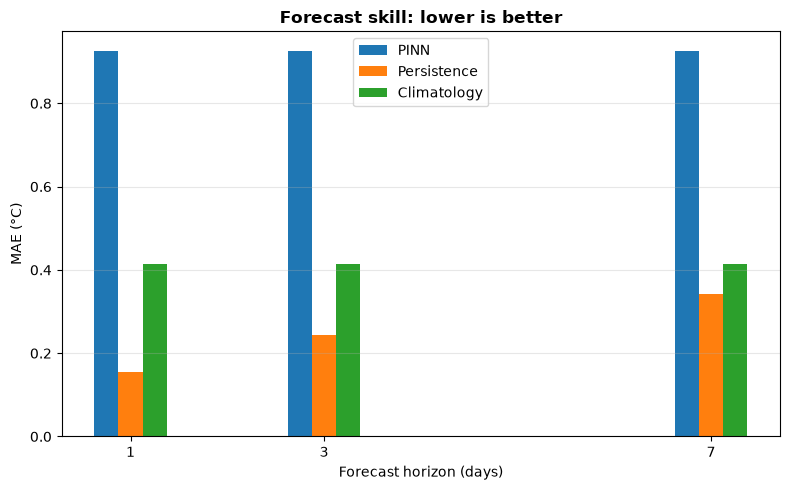


Skill vs persistence (positive = PINN better):
  1-day: -5.006
  3-day: -2.801
  7-day: -1.705


In [11]:
if summary is not None and len(summary):
    fig, ax = plt.subplots(figsize=(8, 5))
    x = summary["horizon_days"].values
    width = 0.25
    ax.bar(x - width, summary["pinn_mae"], width, label="PINN")
    ax.bar(x, summary["persistence_mae"], width, label="Persistence")
    ax.bar(x + width, summary["climatology_mae"], width, label="Climatology")
    ax.set_xticks(x)
    ax.set_xlabel("Forecast horizon (days)")
    ax.set_ylabel("MAE (°C)")
    ax.set_title("Forecast skill: lower is better", fontweight="bold")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\nSkill vs persistence (positive = PINN better):")
    for _, row in summary.iterrows():
        print(f"  {int(row['horizon_days'])}-day: {row['skill_vs_persistence']:+.3f}")
else:
    print("No summary to plot.")

## Part C — Quick DHW risk sanity check

Bleaching risk now leans on **Degree Heating Weeks** (NOAA-style):
- DHW ≥ 4 → warning
- DHW ≥ 8 → danger / mass bleaching risk

In [12]:
from utils import calculate_bleaching_risk

examples = [
    {"label": "Cool / no DHW", "temp": 27.5, "base": 28.0, "dhw": 0.0},
    {"label": "Warm, DHW=4", "temp": 30.0, "base": 28.0, "dhw": 4.0},
    {"label": "Hot, DHW=8", "temp": 31.5, "base": 28.0, "dhw": 8.0},
]

rows = []
for ex in examples:
    r = calculate_bleaching_risk(
        current_temp=ex["temp"],
        baseline_temp=ex["base"],
        recent_temps=[ex["temp"]] * 7,
        dhw=ex["dhw"],
    )
    level = {0: "Healthy", 1: "Warning", 2: "Danger"}[r["risk_level"]]
    rows.append({
        "case": ex["label"],
        "temp": ex["temp"],
        "dhw": ex["dhw"],
        "risk_score": round(r["risk_score"], 3),
        "risk_level": level,
    })

pd.DataFrame(rows)

,case,temp,dhw,risk_score,risk_level
0,Cool / no DHW,27.5,0.0,0.00,Healthy
1,"Warm, DHW=4",30.0,4.0,0.65,Warning
2,"Hot, DHW=8",31.5,8.0,0.90,Danger


## Summary checklist

- [ ] Time test MAE looks reasonable (°C)
- [ ] Location hold-out is not a disaster
- [ ] PINN skill vs persistence is ≥ 0 at short horizons (or you know why not)
- [ ] DHW examples map to Healthy / Warning / Danger as expected

If skill is negative, the PINN is **not** yet a better forecaster than “use yesterday’s SST” — keep iterating on physics weight, advection, and training length.

**Outputs written:**
- `holdout_evaluation.pkl`
- `forecast_validation.csv`
- `forecast_validation_summary.csv`